# 05 · Context design and generation: the PACK and ANSWER stages

**FDE Academy · Accelerator track · Retrieval, RAG and Evals · Lab notebook 5 of 8**

You allocate a working context with hard caps, sweep k against three curves that fight each other, pack whole chunks in a deliberate order, write the citation contract, and let a tree decide when to answer and when to abstain.

| How to run | What it needs | Runs before | Runs after |
|---|---|---|---|
| Run All, top to bottom. Every cell executes offline in under a minute or two. | Python 3.10 or later with numpy, pandas, matplotlib and scikit-learn. `boto3` and `tiktoken` are optional and detected automatically. | Notebook 04. | Notebook 06, which scores what this notebook generates. |

The offline generator is a documented simulator. Where a cell's result depends on a real model reading the context, the cell says so and runs the true experiment when a provider is configured.

## Where this sits on the pipeline

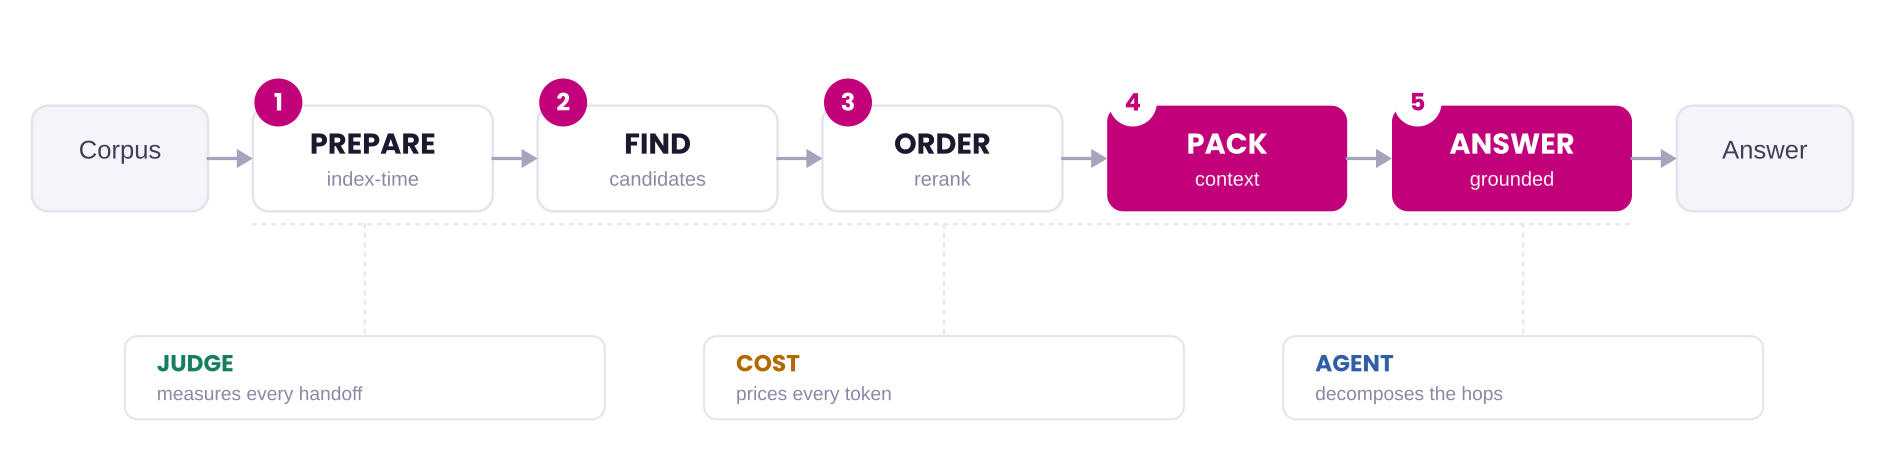

*The context window is a fixed budget. Every distractor admitted costs a slot a gold chunk could have used.*

## 1 · A working context is a budget with hard caps, or it is nothing

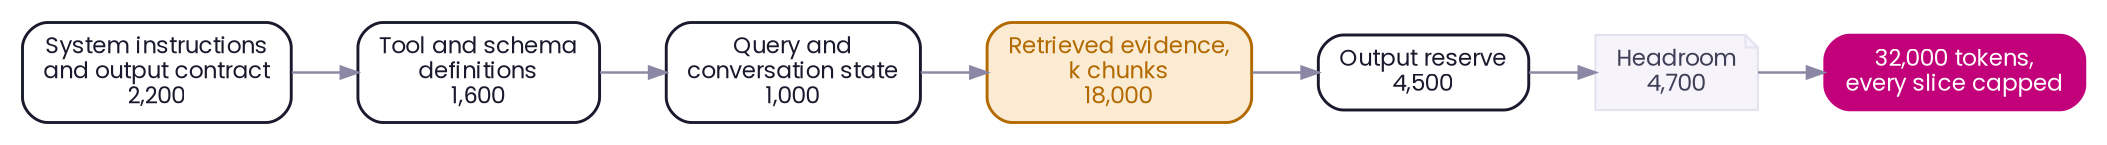

*The 32k allocation from the advanced-track deck, as a config with hard caps. Without a cap, evidence expands until something else is silently truncated.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart LR
    sys["System instructions<br/>and output contract<br/>2,200"]
    tools["Tool and schema<br/>definitions<br/>1,600"]
    q["Query and<br/>conversation state<br/>1,000"]
    ev["Retrieved evidence,<br/>k chunks<br/>18,000"]
    out["Output reserve<br/>4,500"]
    head["Headroom<br/>4,700"]
    cap(["32,000 tokens,<br/>every slice capped"])
    sys --> tools
    tools --> q
    q --> ev
    ev --> out
    out --> head
    head --> cap
    class ev cost
    class head note
    class cap endpt
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

In [1]:
# One-click setup. The notebook runs offline on numpy, pandas, matplotlib, scikit-learn and sqlite3.
# `ragkit` ships in the same folder as this notebook.
import sys, os
from pathlib import Path
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "ragkit").is_dir():
        sys.path.insert(0, str(p)); break
import numpy as np, pandas as pd
import ragkit as rk
from ragkit import table, verdict_style, bars, lines, decision
rk.palette.style()
pd.set_option("display.width", 160)
print("ragkit", rk.__version__, "| provider:", rk.config()["provider"], "| tokenizer:", rk.TOKENIZER)

ragkit 0.1.0 | provider: mock | tokenizer: tiktoken cl100k_base


tokenizer in use: tiktoken cl100k_base
one chunk: 38 words -> 50 tokens (heuristic would say 49)


slice,cap_tokens,what happens when it overflows
System instructions and output contract,2200,"Nothing, but every edit invalidates the prompt cache after it."
Tool and schema definitions,1600,Tool selection degrades before the token limit does.
User query and conversation state,1000,"Summarise older turns, never drop the current question."
"Retrieved evidence, k chunks",18000,"Drop whole chunks by rank, never truncate one mid-way."
Output reserve,4500,The answer is cut off mid-sentence.
Headroom,4700,Absorbs tokenizer variance and a long retry.


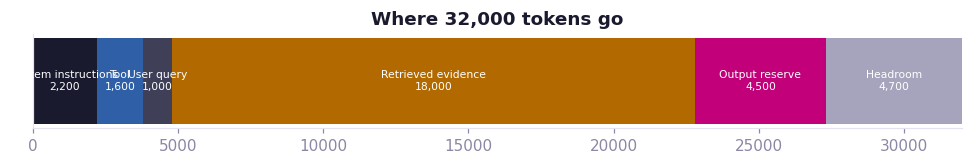

In [2]:
store, chunks, embedder, retriever, generator, questions = rk.bootstrap(chunker="structural")
texts = {c.chunk_id: c.text for c in chunks}; meta = {c.chunk_id: {"source": store.doc(c.doc_id).source, "date": store.doc(c.doc_id).date} for c in chunks}
anchor = rk.ANCHOR; answerable = [q for q in questions if q.gold]
sample = texts["a1:0:63d9a4f8"]
print(f"tokenizer in use: {rk.TOKENIZER}")
print(f"one chunk: {len(sample.split())} words -> {rk.count_tokens(sample)} tokens (heuristic would say {int(len(sample.split()) * 1.3 + 0.5)})")
budget = rk.Budget()
display(table(budget.table(), f"The allocation, total {budget.total:,} tokens"))
import matplotlib.pyplot as plt
fig_, ax = plt.subplots(figsize=(9, 1.6))
left = 0
for (name, cap, _), colour in zip(budget.table().values, [rk.palette.INK, rk.palette.TOOL, rk.palette.SOFT, rk.palette.COST, rk.palette.MAG, rk.palette.DIM]):
    ax.barh(["32k"], [cap], left=left, color=colour); ax.text(left + cap / 2, 0, f"{name.split(',')[0].split(' and ')[0]}\n{cap:,}", ha="center", va="center", fontsize=7, color="white"); left += cap
ax.set_xlim(0, budget.total); ax.set_yticks([]); ax.grid(False); ax.set_title("Where 32,000 tokens go")
plt.tight_layout(); plt.show()

Now the cap does its job. The cell assembles a request for the worked question at rising k and reports which slice overflows first.

In [3]:
tight = rk.Budget(system=2200, tools=1600, query=1000, evidence=300, output=4500, headroom=4700)   # a deliberately small evidence cap to show the overflow
pool = retriever.hybrid(anchor.text, k=50)
rows = []
for k in [2, 4, 6, 8, 12, 16]:
    packed_nocap = rk.pack(pool, texts, evidence_cap=10**9, k=k)
    packed_cap = rk.pack(pool, texts, evidence_cap=tight.evidence, k=k)
    rows.append({"k requested": k, "evidence tokens without cap": packed_nocap.tokens, "over the 300 cap": packed_nocap.tokens > tight.evidence,
                 "chunks packed with cap": len(packed_cap.chunk_ids), "dropped whole, reason": ", ".join(sorted({r for _, r in packed_cap.dropped})) or "none"})
table(pd.DataFrame(rows), "With a hard cap the packer drops whole chunks by rank; it never truncates one, so a citation always resolves to a complete chunk")

k requested,evidence tokens without cap,over the 300 cap,chunks packed with cap,"dropped whole, reason"
2,81,False,2,over k
4,179,False,4,over k
6,250,False,6,over k
8,333,True,7,over token cap
12,497,True,7,over token cap
16,623,True,7,over token cap


| Slice | The cap protects against | What you saw |
|---|---|---|
| Evidence | Evidence growing until the output reserve is eaten and the answer is cut mid-sentence. | Past k=6 the evidence exceeded the 300-token cap and the packer dropped whole chunks with a stated reason. |
| Output reserve | The most visible failure on the list: an answer that stops halfway. | It stayed at 4,500 whatever k was, because the cap is on evidence, not on the total. |
| System and tools | Cache invalidation on every edit, and tool selection degrading before the limit is hit. | Notebook 07 measures the cache side of this. |

## 2 · Top-k: three curves that fight each other

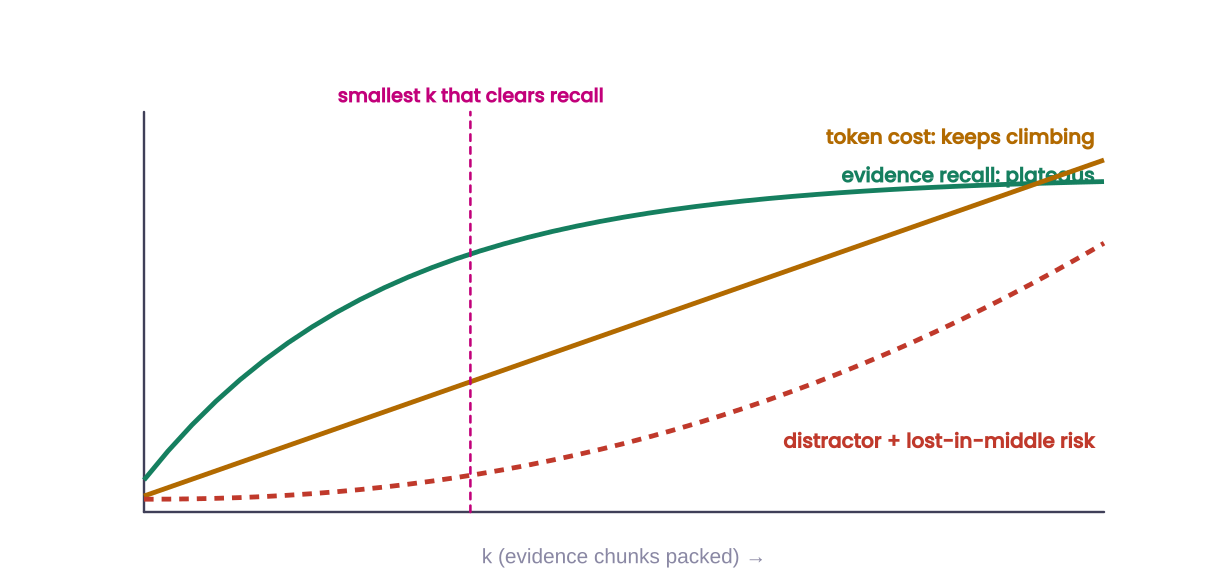

*Own drawing of an established shape. The cell measures it on this corpus.*

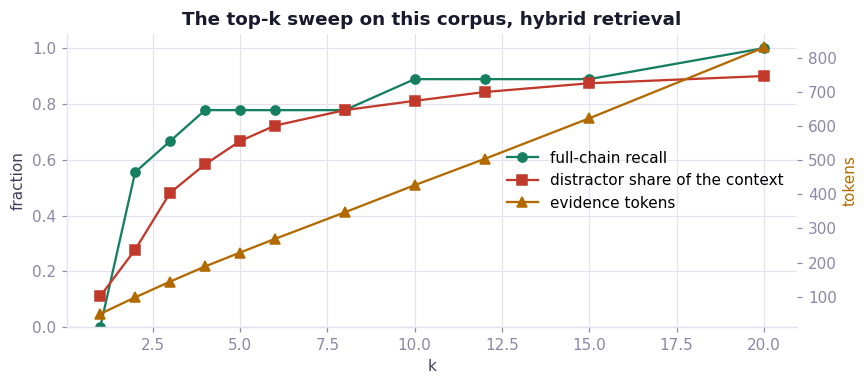

k,full-chain recall,evidence tokens,distractor share
1,0.000,49.000,0.110
2,0.556,98.000,0.280
3,0.667,144.000,0.480
4,0.778,188.000,0.580
5,0.778,229.000,0.670
6,0.778,269.000,0.720
8,0.778,348.000,0.780
10,0.889,427.000,0.810
12,0.889,504.000,0.840
15,0.889,624.000,0.870


question,measured,answer
Does the smallest k with full-chain recall at or above the target fit the evidence cap?,"knee k=10, tokens=427, cap=6000",yes
Outcome,,"pack k=10 chunks, the smallest k at or above the 0.85 target"


In [4]:
ks = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20]
recall_k, tokens_k, distract_k = [], [], []
for k in ks:
    df = rk.run_benchmark(rk.RunConfig(f"k{k}", mode="hybrid", k=k, evidence_cap=50_000), retriever, generator, questions, chunks)
    recall_k.append(float(df[df["type"] != "null"]["full_chain@k"].mean())); tokens_k.append(float(df["evidence_tokens"].mean()))
    fr = []
    for q in answerable:
        p = [cid for cid, _ in retriever.hybrid(q.text, k=k)]; gold = set().union(*rk.gold_chunk_sets(q, chunks)); fr.append(sum(1 for c in p if c not in gold) / len(p))
    distract_k.append(float(np.mean(fr)))
fig_, ax1 = plt.subplots(figsize=(8, 3.6))
ax1.plot(ks, recall_k, marker="o", color=rk.palette.GREEN, label="full-chain recall"); ax1.plot(ks, distract_k, marker="s", color=rk.palette.RED, label="distractor share of the context")
ax1.set_ylabel("fraction"); ax1.set_xlabel("k"); ax1.set_ylim(0, 1.05)
ax2 = ax1.twinx(); ax2.plot(ks, tokens_k, marker="^", color=rk.palette.COST, label="evidence tokens"); ax2.set_ylabel("tokens", color=rk.palette.COST); ax2.grid(False)
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels(); ax1.legend(h1 + h2, l1 + l2, loc="center right")
ax1.set_title("The top-k sweep on this corpus, hybrid retrieval"); plt.tight_layout(); plt.show()
sweep = pd.DataFrame({"k": ks, "full-chain recall": np.round(recall_k, 3), "evidence tokens": np.round(tokens_k, 0), "distractor share": np.round(distract_k, 2)})
display(table(sweep, "Measured"))
KNEE_TREE = [
    {"q": "Does the smallest k with full-chain recall at or above the target fit the evidence cap?", "test": lambda f: f["tokens_at_knee"] <= f["cap"], "yes": f"pack k={0} chunks", "no": "raise the cap or fix retrieval; k cannot buy the missing recall inside this budget", "show": lambda f: f"knee k={f['knee']}, tokens={f['tokens_at_knee']:.0f}, cap={f['cap']}"},
]
target, cap = 0.85, 6000
knee = next(k for k, r in zip(ks, recall_k) if r >= target); tok = tokens_k[ks.index(knee)]
KNEE_TREE[0]["yes"] = f"pack k={knee} chunks, the smallest k at or above the {target:.2f} target"
table(decision(KNEE_TREE, {"knee": knee, "tokens_at_knee": tok, "cap": cap}), "The knee decision, executed")

| If | Then | Because |
|---|---|---|
| Full-chain recall keeps rising with k and the tokens fit the cap. | Take the smallest k at or above the target. Here that is k=10 for a 0.85 target. | Every extra chunk past the knee is mostly distractor, and distractors cost slots, tokens and attention. |
| Recall plateaus below the target no matter how large k is. | Stop turning k. The missing evidence is not in the pool; fix stage one or decompose. | k selects from the pool; it cannot add to it. |
| Recall is met at a small k but the distractor share is still high. | Dedup and rerank before packing. | The share is what the model reads; recall is what it could have read. |

Two of the nine questions never reach full-chain recall until k is 20. Those are the dependent multi-hop questions, and no k below the whole pool fixes them, which is the argument for decomposition in notebook 08 rather than for a bigger context.

## 3 · Packing rules: whole chunks, no twins, a deliberate order

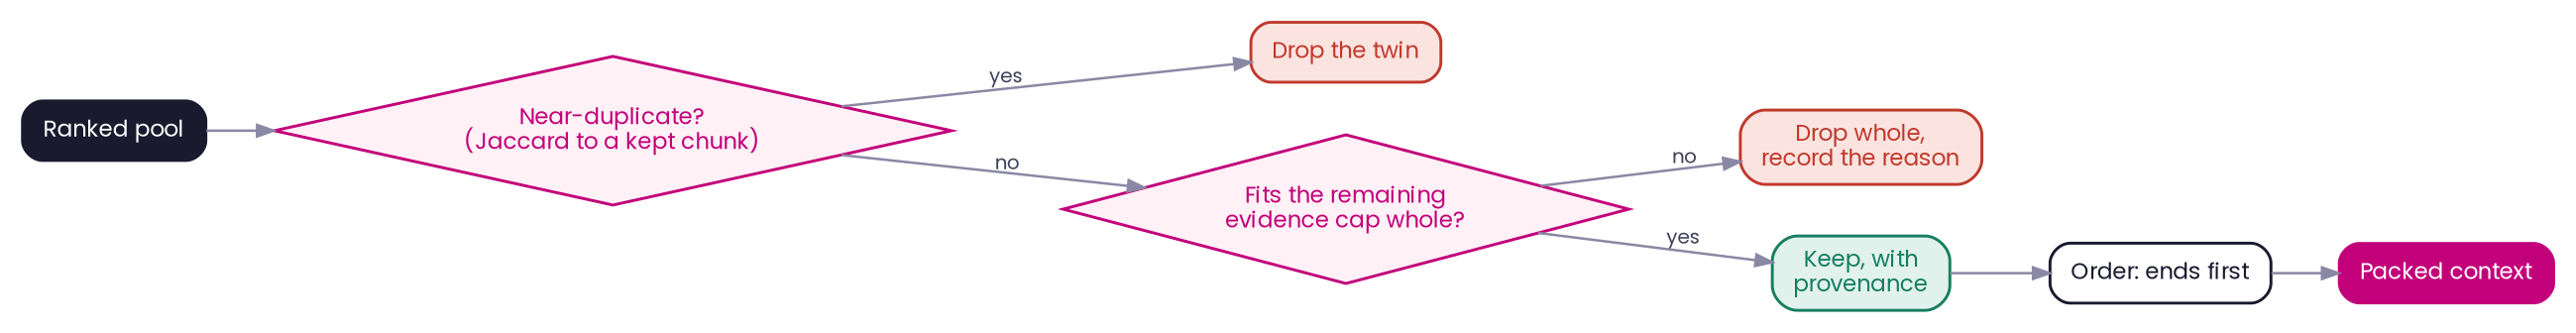

*The packer as it runs in ragkit.pack. Dropped chunks are recorded with the reason so a trace can explain a missing citation.*

<details><summary>Mermaid source</summary>

```mermaid
flowchart LR
    pool(["Ranked pool"])
    dd{"Near-duplicate?<br/>(Jaccard to a kept chunk)"}
    drop1["Drop the twin"]
    fit{"Fits the remaining<br/>evidence cap whole?"}
    drop2["Drop whole,<br/>record the reason"]
    keep["Keep, with<br/>provenance"]
    ord["Order: ends first"]
    ctx(["Packed context"])
    pool --> dd
    dd -->|yes| drop1
    dd -->|no| fit
    fit -->|no| drop2
    fit -->|yes| keep
    keep --> ord
    ord --> ctx
    class pool start
    class dd dec
    class drop1 fail
    class fit dec
    class drop2 fail
    class keep ok
    class ctx endpt
    classDef dec fill:#FFF1F6,stroke:#C2007A,color:#C2007A
    classDef start fill:#1A1A2E,stroke:#1A1A2E,color:#fff
    classDef endpt fill:#C2007A,stroke:#C2007A,color:#fff
    classDef ok fill:#E1F1EB,stroke:#157F5F,color:#157F5F
    classDef fail fill:#FBE3E0,stroke:#C0392B,color:#C0392B
    classDef cost fill:#FBEBD2,stroke:#B26A00,color:#B26A00
    classDef tool fill:#E1EAF5,stroke:#2F5FA6,color:#2F5FA6
    classDef data fill:#F6F4FA,stroke:#8A88A4,color:#3F3F58
    classDef note fill:#F6F4FA,stroke:#E4E2EE,color:#3F3F58
```

</details>

Syndicated copies are how duplicates arrive in a news corpus. The cell injects two copies each of four articles that are gold for no question, then packs the worked question with and without deduplication.

In [5]:
gold_docs = {d for q in questions for d in q.gold_docs}
syndicate = ["g2", "e2", "k3", "r1"]; assert not set(syndicate) & gold_docs
dups = []
for d_id in syndicate:
    d = store.doc(d_id)
    dups.append(rk.Doc(d_id + "b", d.title, "Wire Service", d.date, d.body.replace(" the ", " a ", 1).replace("said", "stated")))
    dups.append(rk.Doc(d_id + "c", d.title, "Syndicated Desk", d.date, d.body.replace(" on ", " during ", 1).replace("percent", "per cent")))
store_d = rk.Store(); q_d = rk.load(store_d); store_d.add_docs(dups)
chunks_d = rk.chunk_corpus(store_d.docs(), "structural"); emb_d = rk.LSAEmbedder().fit([c.text for c in chunks_d]); ret_d = rk.Retriever(store_d, chunks_d, emb_d); texts_d = {c.chunk_id: c.text for c in chunks_d}
pool_d = ret_d.hybrid(anchor.text, k=50)
def twins(packed_ids):
    from ragkit.lexical import tokenize
    out, seen = [], []
    for cid in packed_ids:
        t = set(tokenize(texts_d[cid])); j = max([len(t & s) / len(t | s) for s in seen], default=0.0); out.append(round(j, 2)); seen.append(t)
    return out
before = rk.pack(pool_d, texts_d, evidence_cap=6000, k=5); after = rk.pack(pool_d, texts_d, evidence_cap=6000, k=5, dedup_jaccard=0.7)
side = pd.DataFrame({"slot": range(1, 6), "packed without dedup": before.chunk_ids, "Jaccard to an earlier slot": twins(before.chunk_ids),
                     "packed with dedup at 0.7": after.chunk_ids, "Jaccard after": twins(after.chunk_ids)})
display(table(side, "The worked question's five slots, with the corpus carrying syndicated copies"))
def wasted(cfg):
    df = rk.run_benchmark(cfg, ret_d, generator, q_d, chunks_d, store_d); w = []
    for q in q_d:
        packed = store_d.trace(f"{cfg.name}:{q.qid}")["packed"]; w.append(sum(1 for j in twins(packed) if j >= 0.7))
    return float(np.mean(w)), float(df[df["type"] != "null"]["coverage"].mean())
w0, c0 = wasted(rk.RunConfig("nodedup", mode="hybrid", k=5)); w1, c1 = wasted(rk.RunConfig("dedup", mode="hybrid", k=5, dedup_jaccard=0.7))
table(pd.DataFrame([{"packing": "no dedup", "slots per question spent on a twin": round(w0, 2), "coverage": round(c0, 3)}, {"packing": "dedup at Jaccard 0.7", "slots per question spent on a twin": round(w1, 2), "coverage": round(c1, 3)}]), "Across the benchmark, k=5")

slot,packed without dedup,Jaccard to an earlier slot,packed with dedup at 0.7,Jaccard after
1,g2b:0:1575853f,0.000,g2b:0:1575853f,0.000
2,g2:0:7465c618,0.940,b7:1:eb0b8d13,0.120
3,g2c:0:0b488cb7,0.940,k3:1:3ea2bfbe,0.030
4,b7:1:eb0b8d13,0.130,a1:2:8d2011b6,0.170
5,k3:1:3ea2bfbe,0.030,a1:0:63d9a4f8,0.170


packing,slots per question spent on a twin,coverage
no dedup,0.250,0.833
dedup at Jaccard 0.7,0.000,0.889


| Rule | What you saw | Why it matters |
|---|---|---|
| Never truncate a chunk. | Section 1 dropped whole chunks with a recorded reason when the cap was hit. | A truncated chunk breaks its own citation, and the model reads a sentence that stops mid-fact. |
| Deduplicate before packing. | Without dedup, two of the five slots for the worked question went to copies of the same article; with dedup those slots went to distinct chunks and the gold appointment chunk entered slot 5. | Coverage rose from 0.833 to 0.889 on the benchmark, and a quarter of a slot per question stopped going to a twin. Duplicates are distractors that also cost recall. |
| Order on purpose. | The next section measures why. | A packed list has a front, a middle and a back, and the model does not read them equally. |

## 4 · Where a chunk sits changes whether it is used

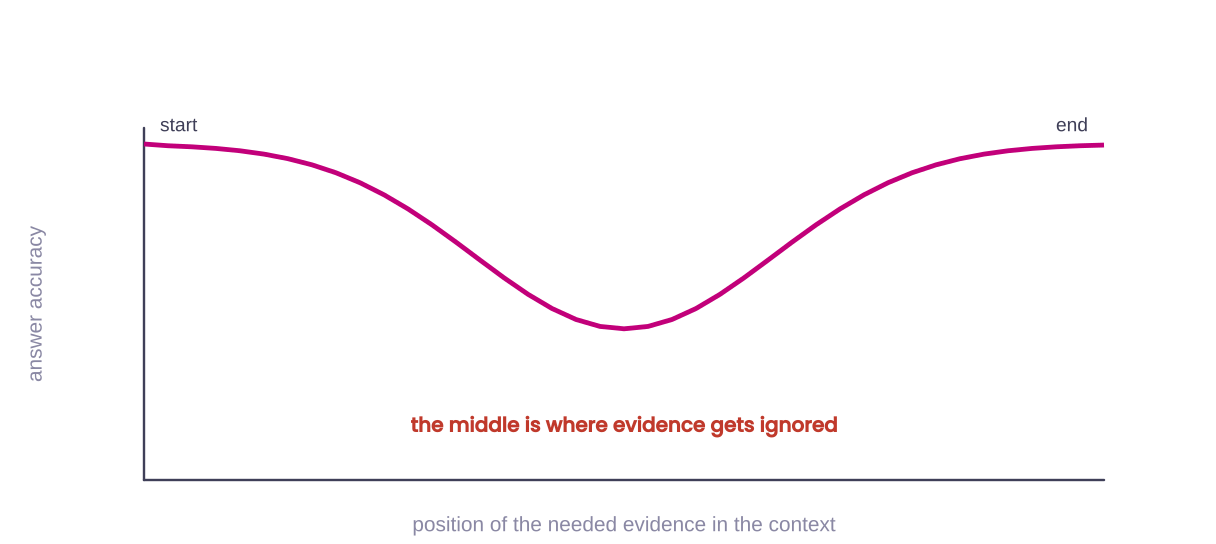

*The shape reported by Liu and colleagues (Lost in the Middle, TACL 2024). The offline cell reproduces the shape by construction, through the simulator's position knob, and says so; with a provider configured the same cell runs the real experiment.*

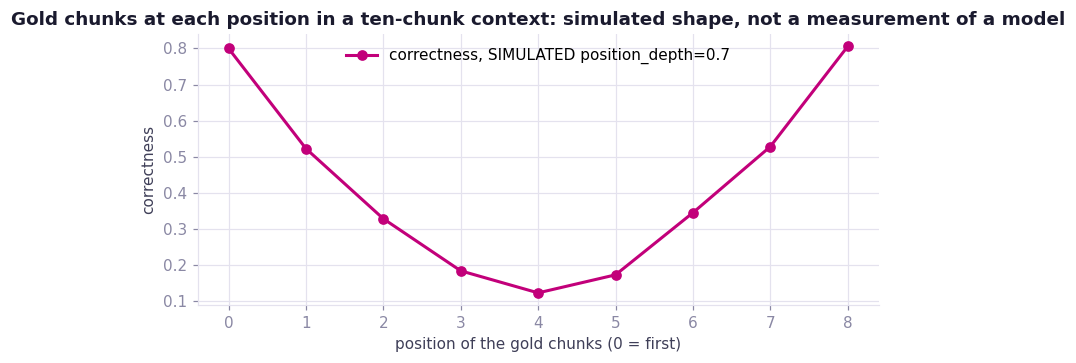

This curve is produced by the simulator's retention knob and is not evidence about any model. Configure a provider to measure the real thing.


In [6]:
positions = list(range(9))
def position_experiment(gen, seeds):
    acc = []
    for p in positions:
        hits = []
        for seed in seeds:
            gen.rng = np.random.default_rng(seed)
            for q in answerable:
                gold = [sorted(s)[0] for s in rk.gold_chunk_sets(q, chunks)]
                others = [cid for cid, _ in retriever.hybrid(q.text, k=30) if cid not in gold][:8]
                ctx = others[:p] + gold + others[p:]
                hits.append(rk.correctness(q, gen.answer(q, ctx, texts).text))
        acc.append(float(np.mean(hits)))
    return acc
if rk.config()["provider"] == "mock":
    sim = position_experiment(rk.MockGenerator(position_depth=0.7), seeds=range(20))
    lines(positions, {"correctness, SIMULATED position_depth=0.7": sim}, "Gold chunks at each position in a ten-chunk context: simulated shape, not a measurement of a model", "position of the gold chunks (0 = first)", "correctness")
    print("This curve is produced by the simulator's retention knob and is not evidence about any model. Configure a provider to measure the real thing.")
else:
    llm = rk.get_llm()
    def real_answer(q, ctx):
        prompt = rk.skeleton(q.text, rk.Packed(ctx, [texts[c] for c in ctx], 0), meta); return llm.generate(prompt)
    acc = []
    for p in positions:
        hits = []
        for q in answerable:
            gold = [sorted(s)[0] for s in rk.gold_chunk_sets(q, chunks)]; others = [cid for cid, _ in retriever.hybrid(q.text, k=30) if cid not in gold][:8]
            hits.append(rk.correctness(q, real_answer(q, others[:p] + gold + others[p:])))
        acc.append(float(np.mean(hits)))
    lines(positions, {f"correctness, {llm.name}": acc}, "Gold chunks at each position in a ten-chunk context: measured", "position of the gold chunks (0 = first)", "correctness")

In [7]:
# the practical response: rank order against ends-first order, on the benchmark, ten seeds each
print("ends-first ordering of ranks 1..10:", [r for r, _ in rk.order_ends_first([(r, 0) for r in range(1, 11)])])
sim_gen = rk.MockGenerator(position_depth=0.7)
res = {}
for order in ["rank", "ends"]:
    vals = [float(rk.summarize(rk.run_benchmark(rk.RunConfig(order, mode="hybrid", k=10, order=order), retriever, sim_gen, questions, chunks, seed=s))["correct"]) for s in range(10)]
    res[order] = (np.mean(vals), np.std(vals))
table(pd.DataFrame([{"order": o, "mean correctness over 10 seeds": round(m, 3), "std": round(sd, 3)} for o, (m, sd) in res.items()]), "Ordering on the benchmark under the simulator, k=10")

ends-first ordering of ranks 1..10: [1, 3, 5, 7, 9, 10, 8, 6, 4, 2]


order,mean correctness over 10 seeds,std
rank,0.808,0.084
ends,0.817,0.062


| If | Then | Because |
|---|---|---|
| Your model shows the U shape on your own evidence positions. | Order the packed list ends first: rank 1 first, rank 2 last, rank 3 second, and so on. | The two strongest chunks land where they are read most, and nothing is dropped to achieve it. |
| The measured gain from ordering is inside the run-to-run noise, as it is on this benchmark. | Report it as no result, and keep the ordering anyway since it costs nothing. | Gold sits at rank 1 or 2 for most questions here, so it is already at the front; notebook 06 measures the noise band that makes this a non-result. |
| You are tempted to fix the middle by packing more. | Do not. | More chunks make the middle longer. |

## 5 · The prompt is a fixed skeleton with a citation contract

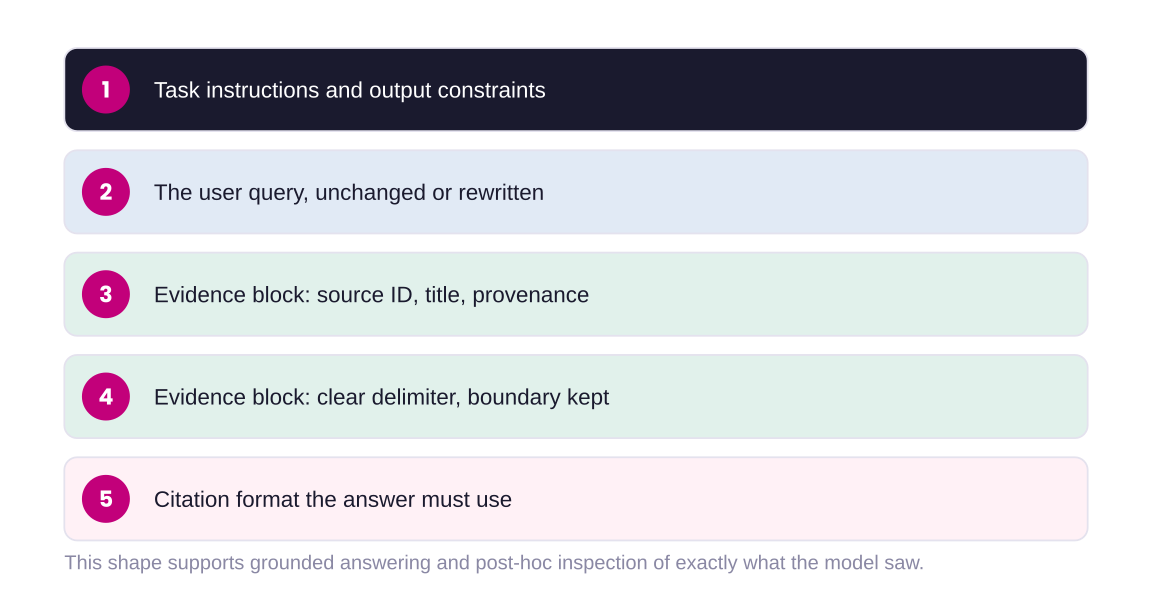

*Own construction, aligned with the advanced-track deck's volatility ordering, which notebook 07 costs.*

In [8]:
packed = rk.pack(retriever.hybrid(anchor.text, k=50), texts, evidence_cap=6000, k=4, order="ends")
prompt = rk.skeleton(anchor.text, packed, meta)
print(prompt[:1400], "\n...\n")
print(f"prompt tokens: {rk.count_tokens(prompt):,} of which evidence {packed.tokens}")
ans = generator.answer(anchor, [sorted(s)[0] for s in rk.gold_chunk_sets(anchor, chunks)], texts)
cites = rk.citations_in(ans.text)
resolved = [(c, c in texts, any(" ".join(span.split()) in " ".join(texts[c].split()) for _, span in anchor.gold)) for c in cites]
table(pd.DataFrame(resolved, columns=["citation", "resolves to a chunk", "chunk carries a gold span"]), f"Citations in: {ans.text}")

<system>
You answer only from the evidence blocks. Every factual claim must cite the block id in square brackets, for example [a1:0:1f2e]. If the evidence does not contain the facts needed, reply exactly: INSUFFICIENT EVIDENCE, followed by which fact is missing. If two blocks conflict, say so and cite both.
</system>

<question>
The person who became CEO of Nord Aerospace in 2026 had earlier taken which company public, and in what year?
</question>

<evidence id="g2:0:7465c618" source="Bloomberg" date="2026-05-14">
Nord Aerospace expands Bergen test site. Nord Aerospace began construction of a second test stand at its Bergen site, chief executive Elena Ruiz said on a call with reporters.
</evidence>

<evidence id="b7:1:eb0b8d13" source="Reuters" date="2023-06-08">
Vega Dynamics shares jump in Nasdaq debut. Chief executive Elena Ruiz, who has run the company since 2020, said the proceeds would fund a second engine plant in Oslo. Ruiz took the company public after three years as chief ex

citation,resolves to a chunk,chunk carries a gold span
a1:0:63d9a4f8,True,True
b7:0:d9956799,True,True


| Skeleton part | What it prevents | How it is enforced |
|---|---|---|
| A stable system block with the output contract, placed first. | Cache misses on every request, and the model inventing its own format. | Notebook 07 measures the cache; the format rule is in `SYSTEM_CONTRACT`. |
| Evidence blocks delimited with an id, a source and a date. | Instructions inside a document being read as instructions, and citations that resolve to nothing. | The block id is the chunk id, so a citation is checked by lookup, as the table above does. |
| An abstention phrase the contract names exactly. | A fluent answer with no support, and a scorer that cannot tell abstention from refusal. | The evaluator in notebook 06 keys on the exact phrase. |
| A conflict rule: say so and cite both. | The model silently picking one of two contradicting numbers. | The next section detects the conflict before generation. |

## 6 · Answer, or abstain with a stated gap

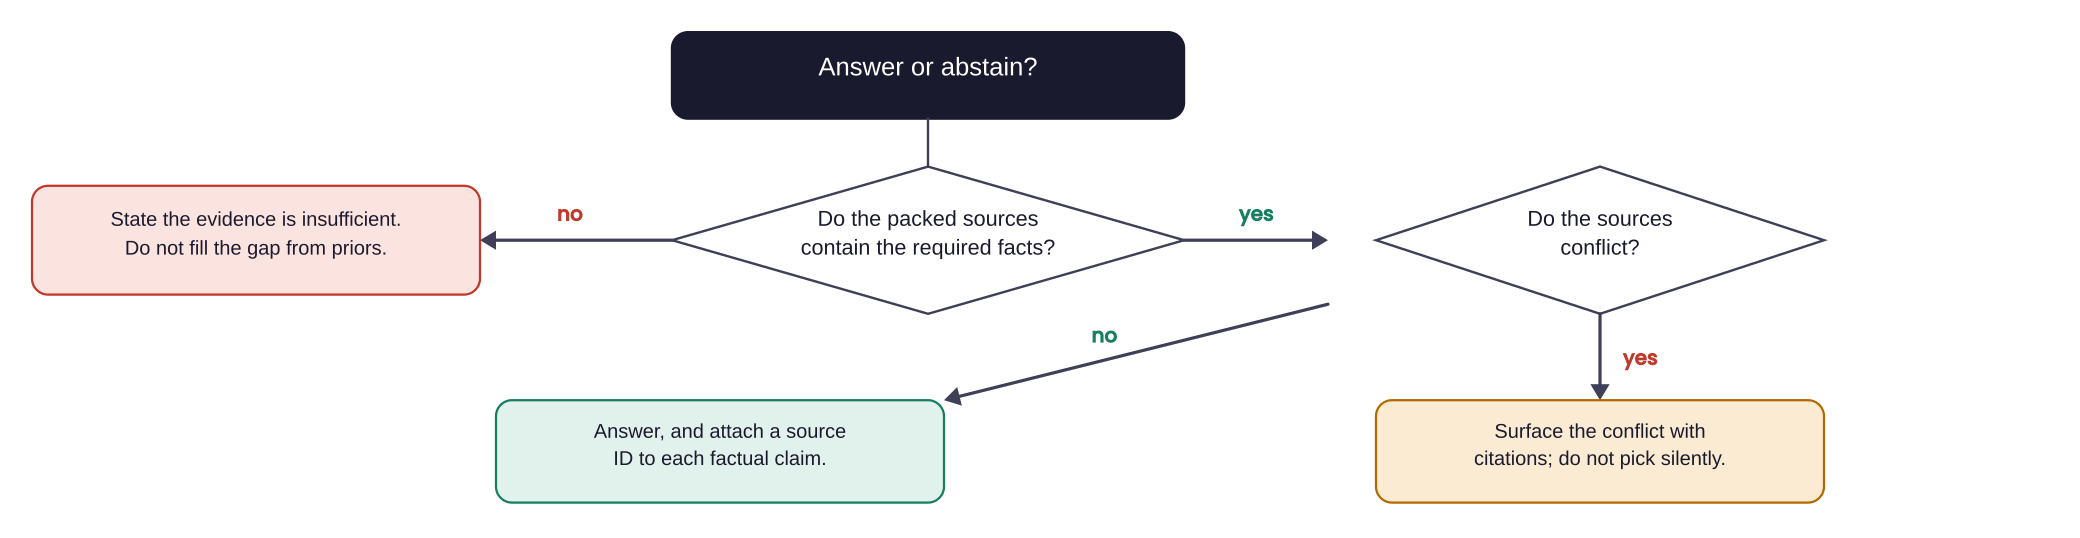

*Own construction. The runner executes it on four packed contexts.*

In [9]:
import re
def numbers(t): return set(re.findall(r"\b\d[\d,.]*\b", t))
def conflict(packed_ids, txt):
    from ragkit.lexical import tokenize
    toks = {c: set(tokenize(txt[c])) for c in packed_ids}
    for i, a in enumerate(packed_ids):
        for b in packed_ids[i + 1:]:
            j = len(toks[a] & toks[b]) / max(1, len(toks[a] | toks[b]))
            if j >= 0.5 and numbers(txt[a]) != numbers(txt[b]) and numbers(txt[a]) and numbers(txt[b]):
                return f"{a} and {b} agree on wording and disagree on a number"
    return ""
ANSWER_TREE = [
    {"q": "Is every required fact covered by the packed evidence?", "test": lambda f: f["coverage"] >= 1.0, "yes": None, "no": "abstain with a stated gap: name the fact that is missing", "show": lambda f: f"coverage={f['coverage']:.2f}"},
    {"q": "Do two packed chunks conflict on a number while agreeing on wording?", "test": lambda f: bool(f["conflict"]), "yes": "answer, state the conflict, cite both chunks", "no": "answer with a citation per fact", "show": lambda f: f["conflict"] or "no conflict"},
]
q04 = next(q for q in questions if q.qid == "q04"); q10 = next(q for q in questions if q.qid == "q10")
texts_c = dict(texts); texts_c["b7:0:conflict"] = texts["b7:0:d9956799"].replace("310 million", "300 million")
cases = {
    "q01 with both gold chunks": ([sorted(s)[0] for s in rk.gold_chunk_sets(anchor, chunks)], anchor, texts),
    "q01 with one gold chunk": ([sorted(rk.gold_chunk_sets(anchor, chunks)[0])[0]], anchor, texts),
    "q10, a null question, top 5": ([c for c, _ in retriever.hybrid(q10.text, k=5)], q10, texts),
    "q04 with a conflicting copy injected": ([sorted(s)[0] for s in rk.gold_chunk_sets(q04, chunks)] + ["b7:0:conflict"], q04, texts_c),
}
for label, (ids_, q, txt) in cases.items():
    cov = rk.coverage(rk.gold_chunk_sets(q, chunks), ids_) if q.gold else 0.0
    display(table(decision(ANSWER_TREE, {"coverage": cov, "conflict": conflict(ids_, txt)}), label))

question,measured,answer
Is every required fact covered by the packed evidence?,coverage=1.00,yes
Do two packed chunks conflict on a number while agreeing on wording?,no conflict,no
Outcome,,answer with a citation per fact


question,measured,answer
Is every required fact covered by the packed evidence?,coverage=0.50,no
Outcome,,abstain with a stated gap: name the fact that is missing


question,measured,answer
Is every required fact covered by the packed evidence?,coverage=0.00,no
Outcome,,abstain with a stated gap: name the fact that is missing


question,measured,answer
Is every required fact covered by the packed evidence?,coverage=1.00,yes
Do two packed chunks conflict on a number while agreeing on wording?,b7:0:d9956799 and b7:0:conflict agree on wording and disagree on a number,yes
Outcome,,"answer, state the conflict, cite both chunks"


| Case | Path the tree took | The generation control that implements it |
|---|---|---|
| Both facts present, no conflict. | Answer with a citation per fact. | The evidence constraint plus the citation format in the contract. |
| One fact present. | Abstain and name the missing fact. | The abstention rule, which the simulator also follows: it says which chain link it could not confirm. |
| A null question. | Abstain. | Coverage is zero by definition, so the model must not reach for the near-miss document. |
| A conflicting copy of a fact. | Answer, state the conflict, cite both. | The conflict rule in the contract. A model that picks one number silently has failed even when it picks the right one. |

## 7 · Why not put everything in the context window?

Below about 200,000 tokens, doing exactly that is often right, as notebook 03's decision showed for this corpus. The cell projects what happens as the corpus grows, at an illustrative input rate of 3 dollars per million tokens, against retrieving k=8 chunks of about 40 tokens.

corpus size (documents),corpus tokens,"everything-in-context, dollars per query",fits a 200k window,"retrieve k=8, dollars per query"
30,2155,0.006,True,0.010
300,21550,0.065,True,0.010
3000,215500,0.646,False,0.010
30000,2155000,6.465,False,0.010
300000,21550000,64.650,False,0.010


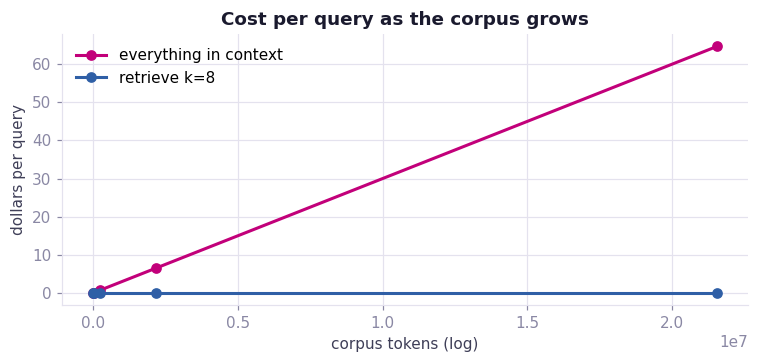

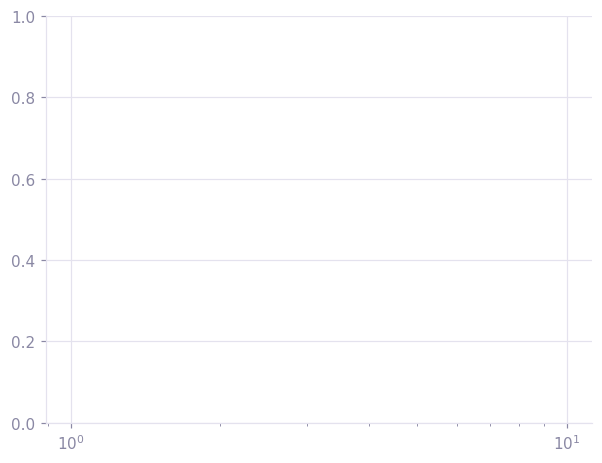

In [10]:
corpus_tokens = sum(rk.count_tokens(d.text) for d in store.docs())
scales = [1, 10, 100, 1000, 10_000]
rate_in = 3.0 / 1e6
rows = []
for s in scales:
    total = corpus_tokens * s
    rows.append({"corpus size (documents)": 30 * s, "corpus tokens": total, "everything-in-context, dollars per query": round(total * rate_in, 4),
                 "fits a 200k window": total <= 200_000, "retrieve k=8, dollars per query": round((8 * 40 + 3000) * rate_in, 4)})
proj = pd.DataFrame(rows)
display(table(proj, "Projection at illustrative rates; the 3,000 is a cached prefix, notebook 07 prices it"))
lines([r["corpus tokens"] for r in rows], {"everything in context": [r["everything-in-context, dollars per query"] for r in rows], "retrieve k=8": [r["retrieve k=8, dollars per query"] for r in rows]},
      "Cost per query as the corpus grows", "corpus tokens (log)", "dollars per query")
plt.gca().set_xscale("log"); plt.show()

| Dimension | Everything in the window | Retrieve, then pack |
|---|---|---|
| Cost per query | Grows with the corpus, so it is paid again on every request. | Flat: a cached prefix plus k chunks. |
| Latency | Grows with the input; a long prefill precedes the first token. | Bounded by k. |
| Position | The gold fact sits in the middle on average, exactly where section 4 showed it is least used. | Ordering puts it at an end. |
| Freshness | Every request re-reads the whole corpus, so freshness is trivial. | The index must be kept fresh, as notebook 03 does. |
| Provenance | The model cites an offset in a wall of text, or nothing. | Each chunk carries an id, a source and a date. |
| The break point | Under about 200,000 tokens, and when the corpus is stable. | Beyond it, or when cost per query matters. |

## Failure points in this stage

| Failure | What you saw | The fix |
|---|---|---|
| Top-k too small | Full-chain recall of 0 at k=1 and 0.56 at k=2. | Sweep k and read the knee; on this corpus k=10 for a 0.85 target. |
| Truncated chunk | Not shown, because the packer refuses to do it. | Drop whole, record the reason. |
| Duplicate chunks | Two of five slots on the worked question went to copies of one article. | Dedup at a Jaccard threshold before packing. |
| Evidence in the middle | The simulated U shape, and the real experiment when a provider is configured. | Ends-first ordering. |
| Unsupported answer | Prevented by the contract: abstention with a stated gap when coverage is short. | The citation contract and the exact abstention phrase. |
| Silent conflict resolution | A conflicting copy was detected before generation. | The conflict rule: say so, cite both. |

## What to carry out of this notebook

| # | The line worth remembering |
|---|---|
| 1 | A working context is a budget with hard caps per slice; without a cap, evidence grows until the answer is cut off. |
| 2 | The top-k sweep is three curves in tension, and the knee is where recall flattens; k cannot add evidence that is not in the pool. |
| 3 | Pack whole chunks, deduplicate first, and order ends first; on this benchmark dedup alone recovered a quarter of a slot per question and lifted coverage. |
| 4 | Position changes whether a chunk is used; the offline curve is simulated and the real one is one config line away. |
| 5 | The prompt is a fixed skeleton with a citation contract, an exact abstention phrase and a conflict rule, so every failure has a scorer. |
| 6 | Everything-in-context is right below about 200,000 tokens and wrong past it, on cost, latency and position. |

**Next: 06 · Evaluation and the release gate.** Every control in this notebook produced something a scorer can check. Notebook 06 writes those scorers out, builds the attribution 2x2 over the whole benchmark, calibrates a judge, measures the noise band, and lets a gate block a change that looks like an improvement.

## Interview corner

| Question an interviewer may ask | What a strong answer does | Red flag |
|---|---|---|
| Why not put the whole knowledge base in the context window? | Gives the 200k break point and the three costs past it: cost per query, latency, position. | Says context windows are big now. |
| How do you pick k? | Sweeps it against full-chain recall, tokens and distractor share, and names the knee. | Picks 5 because it is common. |
| Your assistant answered confidently from a chunk that contradicts another chunk. What went wrong? | Names the missing conflict rule and the silent-choice failure, and adds detection before generation. | Blames the model. |